---
**Title:** Context Parallelism (CP)

**Category:** context-parallelism

**Difficulty:** Advanced

**Estimated Time:** 45 min

---

## Overview

Context Parallelism (CP) lets multiple GPUs share the work of computing attention on long sequences. This notebook builds the idea step by step:

1. Why attention on long sequences blows up memory
2. Splitting the sequence across GPUs
3. The Ring Attention trick — rotating KV blocks
4. Online softmax correction (so it stays numerically exact)
5. Putting it all together with a working simulation
6. How Megatron-LM implements it in practice

### Prerequisites
- Scaled dot-product attention (Q, K, V)

> **Q, K, V?** In attention, the input is projected into three matrices: **Query** (what am I looking for?), **Key** (what do I contain?), and **Value** (what information do I carry). Attention scores come from matching Q against K, then using those scores to weight V.
- [00-gpu-communication](00-gpu-communication.ipynb) — P2P and ring communication patterns
- [04-sequence-parallelism](04-sequence-parallelism.ipynb) — Sequence Parallelism basics

## Concepts & Principles

### Step 1: Attention and the Memory Problem

Let's start tiny. Here's attention with **8 tokens** and **head_dim=4**:

> **head_dim?** Each attention head operates on vectors of this dimension. Smaller than the full model hidden size — e.g., a 4096-dim model with 32 heads has head_dim = 128.

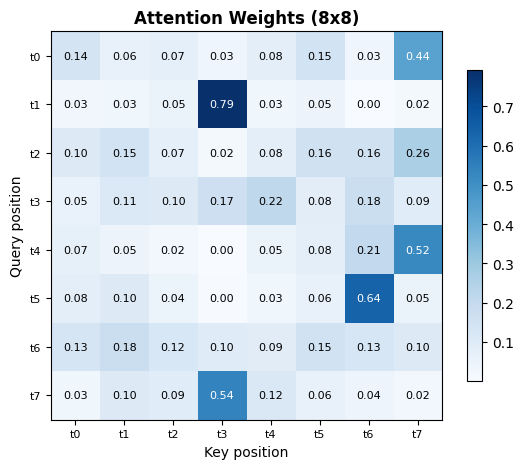

In [1]:
import torch
import numpy as np
from mp_tutorial.viz import draw_attention_heatmap

torch.manual_seed(0)
S, D = 8, 4  # 8 tokens, head_dim = 4
Q = torch.randn(S, D)
K = torch.randn(S, D)
V = torch.randn(S, D)

# Compute attention scores
scale = D ** -0.5
scores = (Q @ K.T) * scale
weights = torch.softmax(scores, dim=-1)

# Visualize: the attention weight matrix is S x S
token_labels = [f"t{i}" for i in range(S)]
draw_attention_heatmap(weights, title=f"Attention Weights ({S}x{S})", token_labels=token_labels)

That 8x8 matrix is small. But attention scales as **S x S** — double the sequence, 4x the memory:

| Sequence length | Score matrix size | Memory (FP16) |
|---|---|---|
| 4,096 | 16M | 32 MB |
| 32,768 | 1B | 2 GB |
| 131,072 | 17B | 32 GB |

> **FP16?** Half-precision floating point — each number uses 2 bytes instead of 4 (FP32). Standard for training large models to save memory.

At 128K tokens, the score matrix alone exceeds most GPUs. **Context Parallelism fixes this.**

### Step 2: Split the Sequence Across GPUs

The idea: give each GPU a **chunk** of the sequence. With 2 GPUs and 8 tokens, each gets 4 tokens.

> **Chunk?** Just a contiguous slice of the sequence. If you have 8 tokens and 2 GPUs, tokens 0-3 are chunk 0, tokens 4-7 are chunk 1.

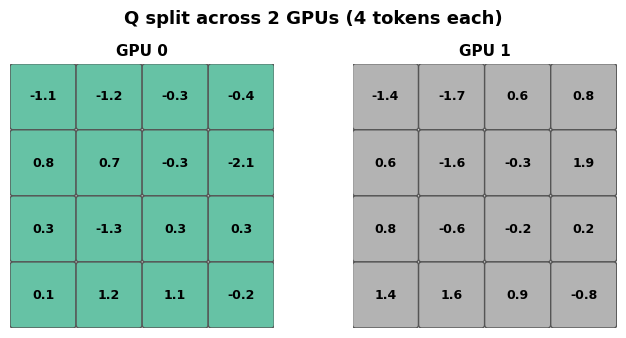

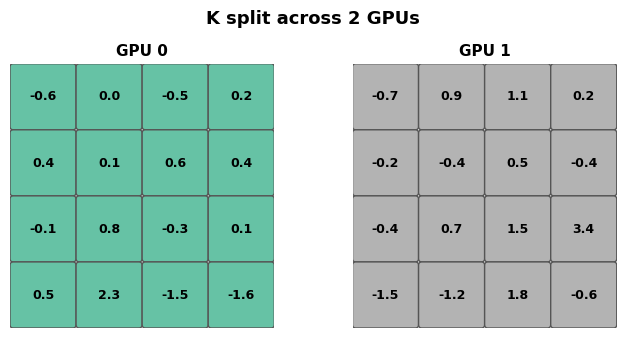

In [2]:
from mp_tutorial.viz import draw_tensor_blocks

num_gpus = 2
chunk_size = S // num_gpus

# Split Q, K, V
q_chunks = list(Q.split(chunk_size, dim=0))
k_chunks = list(K.split(chunk_size, dim=0))
v_chunks = list(V.split(chunk_size, dim=0))

draw_tensor_blocks(q_chunks, title=f"Q split across {num_gpus} GPUs ({chunk_size} tokens each)")
draw_tensor_blocks(k_chunks, title=f"K split across {num_gpus} GPUs")

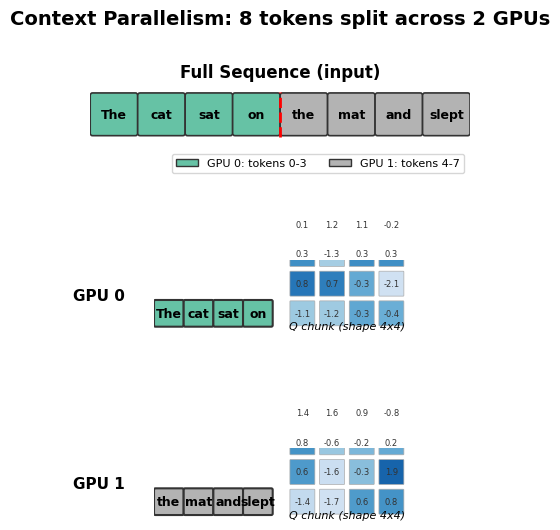

In [3]:
from mp_tutorial.viz import draw_context_partition

# A real sentence split across 2 GPUs — each GPU gets half the context
tokens = ["The", "cat", "sat", "on", "the", "mat", "and", "slept"]
draw_context_partition(tokens, num_gpus=2, q_chunks=q_chunks,
                        title="Context Parallelism: 8 tokens split across 2 GPUs")

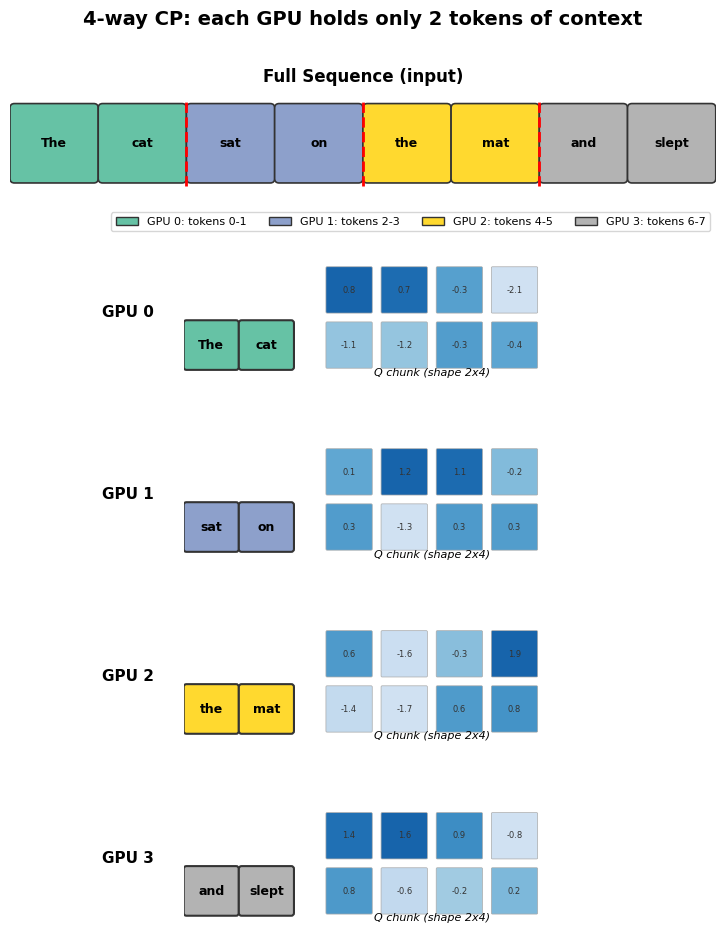

In [4]:
# Same sentence, now with 4 GPUs — each gets just 2 tokens
q4 = list(Q.split(2, dim=0))
draw_context_partition(tokens, num_gpus=4, q_chunks=q4,
                        title="4-way CP: each GPU holds only 2 tokens of context")

Each GPU has its **local Q chunk**. But to compute attention correctly, each Q needs to see **ALL** K and V — not just its local chunk.

The full attention matrix has 4 tiles. Let's see them:

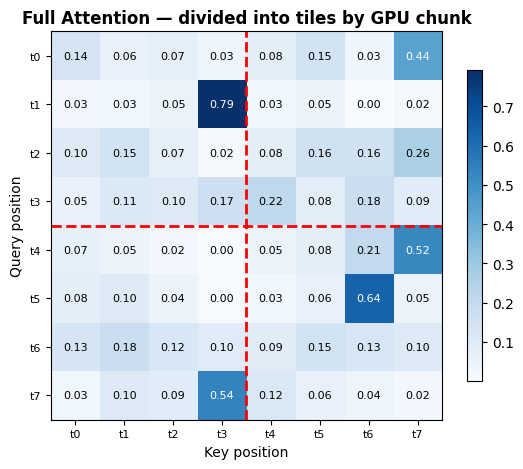

In [5]:
# Show the full attention matrix with chunk boundaries
draw_attention_heatmap(
    weights,
    title="Full Attention — divided into tiles by GPU chunk",
    chunk_boundaries=[chunk_size],
    token_labels=token_labels
)

The red lines show the chunk boundaries. Each GPU needs to compute **its row of tiles** (one tile per KV chunk).

> **Tile?** A sub-block of the full attention matrix. With 2 GPUs, the S×S matrix splits into a 2×2 grid of tiles, each (S/2)×(S/2).

- GPU 0 needs: tile(Q0, K0) and tile(Q0, K1)
- GPU 1 needs: tile(Q1, K0) and tile(Q1, K1)

But each GPU starts with only its own KV chunk. How does it get the other one?

### Step 3: Ring Attention — Rotating KV Blocks

Instead of all-gathering all KV to every GPU (expensive!), we **pass KV blocks around a ring**:

> **P2P (point-to-point)?** Direct GPU-to-GPU communication — GPU 0 sends data directly to GPU 1, without going through a central coordinator. Faster than broadcasting to everyone.

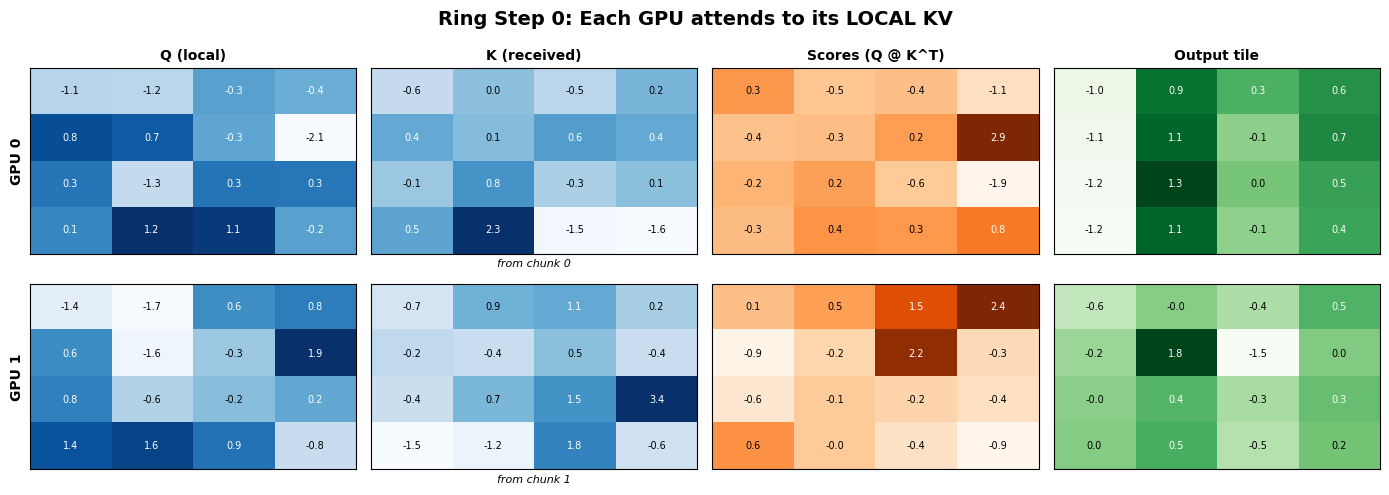

In [6]:
from mp_tutorial.viz import draw_ring_step_dataflow

# Step 0: each GPU uses its LOCAL KV
local_k = list(k_chunks)  # GPU 0 has K0, GPU 1 has K1
local_v = list(v_chunks)

step0_scores = []
step0_outputs = []
for gpu in range(num_gpus):
    s = (q_chunks[gpu] @ local_k[gpu].T) * scale
    w = torch.softmax(s, dim=-1)
    step0_scores.append(s)
    step0_outputs.append(w @ local_v[gpu])

draw_ring_step_dataflow(
    q_chunks, local_k, local_v, step0_scores, step0_outputs,
    step=0, num_gpus=num_gpus,
    title="Ring Step 0: Each GPU attends to its LOCAL KV"
)

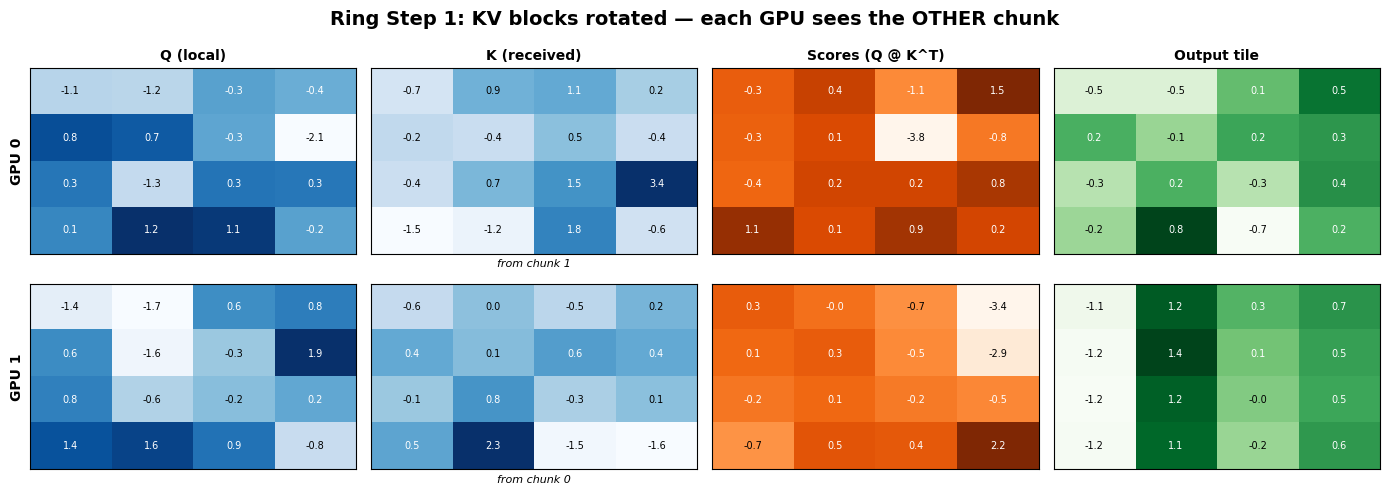

In [7]:
from mp_tutorial.distributed import simulate_p2p_kv_exchange

# Rotate KV one step: GPU 0 gets K1, GPU 1 gets K0
local_k = simulate_p2p_kv_exchange(local_k)
local_v = simulate_p2p_kv_exchange(local_v)

step1_scores = []
step1_outputs = []
for gpu in range(num_gpus):
    s = (q_chunks[gpu] @ local_k[gpu].T) * scale
    w = torch.softmax(s, dim=-1)
    step1_scores.append(s)
    step1_outputs.append(w @ local_v[gpu])

draw_ring_step_dataflow(
    q_chunks, local_k, local_v, step1_scores, step1_outputs,
    step=1, num_gpus=num_gpus,
    title="Ring Step 1: KV blocks rotated — each GPU sees the OTHER chunk"
)

After 2 steps (= num_gpus), every GPU has attended to every KV chunk! No GPU ever held the full sequence.

But there's a catch — we can't just average the two partial outputs. We need **online softmax correction**.

### Step 4: Online Softmax Correction

The problem: softmax across the FULL key dimension requires seeing ALL scores at once. But we compute scores one tile at a time.

The solution: track a running max and sum-of-exps, and **rescale** the accumulated output as new tiles arrive. Let's see it on a concrete example:

> **Online algorithm?** An algorithm that processes data piece by piece and maintains a running result, rather than needing all data at once. Here, we accumulate attention results tile-by-tile without ever storing the full S×S matrix.

In [8]:
# Walk through online softmax correction for GPU 0
q0 = q_chunks[0]  # (4, 4)
k0_orig = k_chunks[0]  # K from chunk 0
k1_orig = k_chunks[1]  # K from chunk 1

print("=== GPU 0: Online Softmax Correction ===\n")

# --- Tile 0: Q0 @ K0 ---
scores_t0 = (q0 @ k0_orig.T) * scale
m0 = scores_t0.max(dim=-1, keepdim=True).values
exp0 = torch.exp(scores_t0 - m0)
l0 = exp0.sum(dim=-1, keepdim=True)
o0 = exp0 @ v_chunks[0]

print("Tile 0 (Q0 x K0):")
print(f"  scores shape: {scores_t0.shape}")
print(f"  row max (m):  {m0.squeeze().tolist()}")
print(f"  sum(exp):     {l0.squeeze().tolist()}")

# --- Tile 1: Q0 @ K1 ---
scores_t1 = (q0 @ k1_orig.T) * scale
m1 = scores_t1.max(dim=-1, keepdim=True).values
exp1 = torch.exp(scores_t1 - m1)
l1 = exp1.sum(dim=-1, keepdim=True)
o1 = exp1 @ v_chunks[1]

print(f"\nTile 1 (Q0 x K1):")
print(f"  row max (m):  {m1.squeeze().tolist()}")
print(f"  sum(exp):     {l1.squeeze().tolist()}")

# --- Merge: online correction ---
m_new = torch.maximum(m0, m1)
corr0 = torch.exp(m0 - m_new)  # rescale factor for tile 0
corr1 = torch.exp(m1 - m_new)  # rescale factor for tile 1
l_merged = corr0 * l0 + corr1 * l1
o_merged = (corr0 * o0 + corr1 * o1) / l_merged

print(f"\nMerged:")
print(f"  new max:        {m_new.squeeze().tolist()}")
print(f"  correction t0:  {corr0.squeeze().tolist()}")
print(f"  correction t1:  {corr1.squeeze().tolist()}")

# Verify against standard attention for GPU 0's rows
ref = (torch.softmax((q0 @ torch.cat([k0_orig, k1_orig]).T) * scale, dim=-1)
       @ torch.cat([v_chunks[0], v_chunks[1]]))
print(f"\nMax error vs standard attention: {(o_merged - ref).abs().max():.1e}")

=== GPU 0: Online Softmax Correction ===

Tile 0 (Q0 x K0):
  scores shape: torch.Size([4, 4])
  row max (m):  [0.3350312113761902, 2.9286444187164307, 0.17994588613510132, 0.8319642543792725]
  sum(exp):     [2.170938014984131, 1.1392958164215088, 2.3128669261932373, 2.5606918334960938]

Tile 1 (Q0 x K1):
  row max (m):  [1.464674472808838, 0.09878557920455933, 0.7662959098815918, 1.0671123266220093]
  sum(exp):     [1.5841343402862549, 2.0813677310943604, 2.4870407581329346, 2.625109910964966]

Merged:
  new max:        [1.464674472808838, 2.9286444187164307, 0.7662959098815918, 1.0671123266220093]
  correction t0:  [0.32314854860305786, 1.0, 0.556354284286499, 0.7904537916183472]
  correction t1:  [1.0, 0.05902118980884552, 1.0, 1.0]

Max error vs standard attention: 1.2e-07


The correction factors `exp(m_old - m_new)` rescale previous accumulations when a new tile has a larger max. This is the exact same trick used in FlashAttention — Ring Attention just applies it across GPUs.

**Update rule per tile:**

$$m_{\text{new}} = \max(m, m_k), \quad \ell_{\text{new}} = e^{m - m_{\text{new}}} \ell + e^{m_k - m_{\text{new}}} \ell_k, \quad O_{\text{new}} = e^{m - m_{\text{new}}} O + e^{m_k - m_{\text{new}}} O_k$$

## Visual Illustrations

### The Complete Ring Attention Flow (4 GPUs)

Now let's scale up to 4 GPUs and watch the full ring:

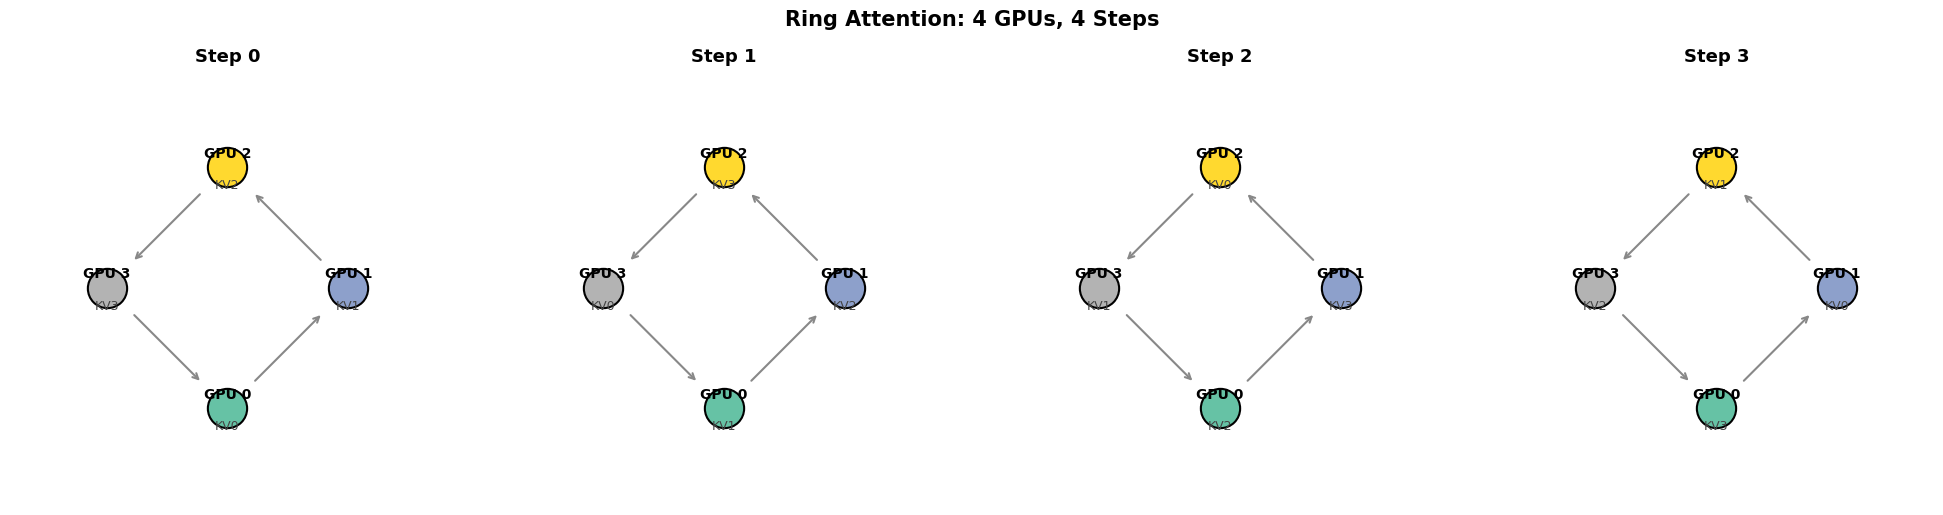

In [9]:
from mp_tutorial.viz import draw_ring_attention_steps

draw_ring_attention_steps(num_gpus=4, num_steps=4, title="Ring Attention: 4 GPUs, 4 Steps")

### Memory Scaling

The payoff: with N GPUs, each GPU only materializes one (S/N) x (S/N) tile at a time.

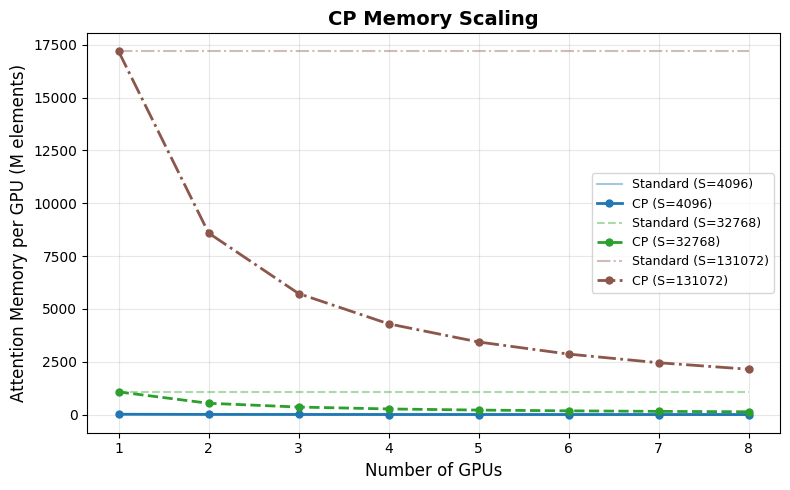

In [10]:
from mp_tutorial.viz import draw_cp_memory_scaling

draw_cp_memory_scaling(seq_lengths=[4096, 32768, 131072], max_gpus=8)

## Application in LLMs

| Dimension | What it splits | Typical scale |
|---|---|---|
| **DP** | Batch | 64-1024x |
| **TP** | Weight matrices / attention heads | 2-8x (within node) |
| **SP** | LayerNorm, Dropout activations | Same as TP |
| **CP** | Attention Q/K/V along sequence | 2-16x |
| **PP** | Layers | 4-16x |


> **NVLink?** A high-speed direct link between GPUs within the same machine (node). Much faster than going over the network, which is why TP is typically limited to GPUs connected by NVLink.

CP is orthogonal to TP/SP — TP splits **heads**, CP splits **sequence**. They compose.

**Used by:** Megatron-LM (`--context-parallel-size`), Llama 3.1 (128K context training), DeepSpeed Ulysses (all-to-all variant).

## Hands-on Code

### Full Ring Attention Simulation

Let's run the complete algorithm and verify it matches standard attention:

In [11]:
from mp_tutorial.distributed import check_gpu_env
check_gpu_env()

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


In [12]:
from mp_tutorial.distributed import simulate_ring_attention

torch.manual_seed(42)
S, D, N = 32, 16, 4
Q = torch.randn(S, D)
K = torch.randn(S, D)
V = torch.randn(S, D)

# Ring Attention
ring_out = simulate_ring_attention(Q, K, V, num_gpus=N, verbose=True)

# Standard attention
ref = torch.softmax((Q @ K.T) * (D ** -0.5), dim=-1) @ V

print(f"\nMax error: {(ring_out - ref).abs().max():.1e}")
print(f"Match: {torch.allclose(ring_out, ref, atol=1e-5)}")

  Step 0: GPU 0 attends to KV from chunk 0
  Step 0: GPU 1 attends to KV from chunk 1
  Step 0: GPU 2 attends to KV from chunk 2
  Step 0: GPU 3 attends to KV from chunk 3
  Step 1: GPU 0 attends to KV from chunk 1
  Step 1: GPU 1 attends to KV from chunk 2
  Step 1: GPU 2 attends to KV from chunk 3
  Step 1: GPU 3 attends to KV from chunk 0
  Step 2: GPU 0 attends to KV from chunk 2
  Step 2: GPU 1 attends to KV from chunk 3
  Step 2: GPU 2 attends to KV from chunk 0
  Step 2: GPU 3 attends to KV from chunk 1
  Step 3: GPU 0 attends to KV from chunk 3
  Step 3: GPU 1 attends to KV from chunk 0
  Step 3: GPU 2 attends to KV from chunk 1
  Step 3: GPU 3 attends to KV from chunk 2

Max error: 3.0e-07
Match: True


### Scaling Test

More GPUs = same result, just split differently:

In [13]:
from mp_tutorial.formatting import comparison_table

torch.manual_seed(123)
S, D = 64, 32
Q = torch.randn(S, D)
K = torch.randn(S, D)
V = torch.randn(S, D)
ref = torch.softmax((Q @ K.T) * (D ** -0.5), dim=-1) @ V

rows = []
for n_gpus in [2, 4, 8]:
    out = simulate_ring_attention(Q, K, V, num_gpus=n_gpus)
    err = (out - ref).abs().max().item()
    rows.append([str(n_gpus), str(S // n_gpus), f"{err:.1e}",
                 "yes" if torch.allclose(out, ref, atol=1e-5) else "no"])

comparison_table(
    ["GPUs", "Chunk size", "Max error", "Match"],
    rows,
    title="Ring Attention correctness across GPU counts"
)

GPUs,Chunk size,Max error,Match
2,32,2.4e-07,yes
4,16,1.8e-07,yes
8,8,4.2e-07,yes


> **GPU Required** — Run the following cell on a multi-GPU machine (4+ GPUs recommended).

In [ ]:
# [GPU-REQUIRED]
# Real distributed Ring Attention with torch.distributed
# Launch with: torchrun --nproc_per_node=4 this_script.py

import torch
import torch.distributed as dist

def ring_attention_distributed(q_local, k_local, v_local, group=None):
    """Ring Attention with real P2P communication."""
    rank = dist.get_rank(group)
    world_size = dist.get_world_size(group)
    chunk_size, head_dim = q_local.shape
    scale = head_dim ** -0.5

    m = torch.full((chunk_size, 1), float("-inf"), device=q_local.device)
    l = torch.zeros(chunk_size, 1, device=q_local.device)
    o = torch.zeros_like(q_local)

    k_recv = torch.empty_like(k_local)
    v_recv = torch.empty_like(v_local)
    k_curr, v_curr = k_local, v_local

    for step in range(world_size):
        # Start async P2P BEFORE compute (overlap comm + compute)
        if step < world_size - 1:
            send_rank = (rank + 1) % world_size
            recv_rank = (rank - 1) % world_size
            send_k = dist.isend(k_curr, dst=send_rank, group=group)
            send_v = dist.isend(v_curr, dst=send_rank, group=group)
            recv_k = dist.irecv(k_recv, src=recv_rank, group=group)
            recv_v = dist.irecv(v_recv, src=recv_rank, group=group)

        # Compute attention tile
        scores = (q_local @ k_curr.T) * scale
        tile_max = scores.max(dim=-1, keepdim=True).values
        tile_exp = torch.exp(scores - tile_max)
        tile_sum = tile_exp.sum(dim=-1, keepdim=True)
        tile_out = tile_exp @ v_curr

        # Online softmax correction
        m_new = torch.maximum(m, tile_max)
        l = torch.exp(m - m_new) * l + torch.exp(tile_max - m_new) * tile_sum
        o = torch.exp(m - m_new) * o + torch.exp(tile_max - m_new) * tile_out
        m = m_new

        if step < world_size - 1:
            send_k.wait(); send_v.wait()
            recv_k.wait(); recv_v.wait()
            k_curr, v_curr = k_recv.clone(), v_recv.clone()

    return o / l

# dist.init_process_group("nccl")
# rank = dist.get_rank()
# ... split Q, K, V and call ring_attention_distributed() ...

## Megatron Reference

Megatron-LM implements CP in `megatron/core/transformer/dot_product_attention.py`.

In [14]:
from mp_tutorial.formatting import code_reference

code_reference(
    code="""# Key design choices in Megatron's Ring Attention:
#
# 1. Communication-Computation Overlap
#    - isend/irecv for KV launched BEFORE compute
#    - GPU computes attention tile while network transfers next KV block
#
# 2. Causal Mask Optimization
#    - For autoregressive models, GPU i skips KV chunks from
#      positions > i (future tokens can't attend to)
#    - Saves ~50% of ring steps for causal models
#
# 3. CP + TP Integration
#    - CP group: splits sequence dimension
#    - TP group: splits attention heads
#    - Orthogonal — both active in same forward pass
#    - Total GPUs = DP x TP x PP x CP""",
    source="Megatron-LM",
    filepath="megatron/core/transformer/dot_product_attention.py"
)

## Summary & Further Reading

**Key Takeaways:**
- CP distributes attention across GPUs: per-GPU memory goes from O(S^2) to O(S^2/N)
- Ring Attention rotates KV blocks around a ring — each GPU only holds one chunk at a time
- Online softmax correction makes tiled attention numerically exact (same as FlashAttention's trick)
- CP is orthogonal to TP/SP — TP splits heads, CP splits sequence, they compose cleanly
- Communication overlaps with computation; causal masking skips ~50% of ring steps

> **Causal mask?** In autoregressive (left-to-right) models, token i can only attend to tokens 0..i, not future tokens. The causal mask enforces this by blocking attention to positions ahead in the sequence.

**Further Reading:**
- [Ring Attention with Blockwise Transformers](https://arxiv.org/abs/2310.01889) — Liu et al., 2023
- [FlashAttention-2](https://arxiv.org/abs/2307.08691) — Dao, 2023 (online softmax correction origin)
- [Megatron-LM](https://github.com/NVIDIA/Megatron-LM) — NVIDIA's distributed training framework
- [DeepSpeed Ulysses](https://arxiv.org/abs/2309.14509) — all-to-all CP variant